Bibliotecas

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast

Puxando o excel de negociações

In [84]:
df = pd.read_excel(r'C:\Users\Orçamento\OneDrive - GRUPO RETEC\02. Engenharia\Dep. Orçamentos\POWERBI\AUTOMACAO RD\data\negociacoes_2024.xlsx')

Colunas que queremos visualizar

In [85]:
df.columns

Index(['_id', 'id', 'name', 'amount_montly', 'amount_unique', 'amount_total',
       'prediction_date', 'markup', 'last_activity_at', 'interactions',
       'markup_last_activities', 'created_at', 'updated_at', 'rating',
       'markup_created', 'last_activity_content', 'user_changed', 'hold',
       'win', 'closed_at', 'contacts', 'deal_custom_fields', 'deal_products',
       'organization._id', 'organization.id', 'organization.name',
       'organization.address', 'organization.address_latitude',
       'organization.address_longitude', 'organization.user._id',
       'organization.user.id', 'organization.user.name',
       'organization.user.email', 'organization.organization_segments',
       'user._id', 'user.id', 'user.name', 'user.nickname', 'user.email',
       'deal_stage._id', 'deal_stage.id', 'deal_stage.name',
       'deal_stage.nickname', 'deal_stage.created_at', 'deal_stage.updated_at',
       'stop_time_limit.expiration_date_time', 'stop_time_limit.expired',
       'stop

In [86]:
colunas = [
    "id", "name",'Proposta Nº','organization.name','Nome da Obra','Unidade de Negócio','Fator','Local da Obra (Estado)',
    'Local da Obra (Cidade)','Produtos (Representação)',
    'Fábrica (Representação)','Orçamentista', "amount_total", "amount_unique", "markup",
    "created_at", "closed_at", "last_activity_at",
    "interactions", "win", "deal_stage.name", "user.id", "user.name",
    "deal_lost_reason.name",    
]

In [87]:
df_rep = df[df['user.name'].isin(['Bruno Crispim', 'Gabriel  Bento'])]
df_rep = df_rep[colunas].copy()
df_rep.loc[:, "Fator"] = (
    df_rep["Fator"]
    .astype(str)
    .str.replace(",", ".", regex=False)
    .astype(float, errors="ignore")
)

In [88]:
df_rep

,id,name,Proposta Nº,organization.name,Nome da Obra,Unidade de Negócio,Fator,Local da Obra (Estado),Local da Obra (Cidade),Produtos (Representação),...,markup,created_at,closed_at,last_activity_at,interactions,win,deal_stage.name,user.id,user.name,deal_lost_reason.name
10,67707f3211d1b80014cbe631,NCT-X 7908-24 - JML CONSTRUTORA - MAX - 16.12....,NCT-X 7908-24 - JML CONSTRUTORA - MAX - 16.12....,JML CONSTRUTORA LTDA,ObraMax,Representação,1,Mato Grosso (MT),Cuiabá,['FAN COIL'],...,future,2024-12-28T19:44:03.130-03:00,NaN,NaN,0,NaN,Conc. Em Andamento,651af445559e310016d78cfb,Gabriel Bento,NaN
11,67707e8f8d159600183d9389,NCD 0019-24 - JML CONSTRUTORA - OBRA MAX - 03....,NCD 0019-24 - JML CONSTRUTORA - OBRA MAX - 03....,JML CONSTRUTORA LTDA,ObraMax,Representação,1,Mato Grosso (MT),Cuiabá,['VRF'],...,future,2024-12-28T19:41:19.185-03:00,NaN,NaN,0,NaN,Conc. Em Andamento,651af445559e310016d78cfb,Gabriel Bento,NaN
12,67707e06210a53001b824084,NCS 0036-24 - JML CONSTRUTORA - OBRA MAX - 03....,NCS 0036-24 - JML CONSTRUTORA - OBRA MAX - 03....,JML CONSTRUTORA LTDA,ObraMax,Representação,1,Mato Grosso (MT),Cuiabá,['MINI SPLIT'],...,future,2024-12-28T19:39:02.960-03:00,NaN,NaN,0,NaN,Conc. Em Andamento,651af445559e310016d78cfb,Gabriel Bento,NaN
13,67706cf05768a90014c75888,NCT 7860-24 - JML CONSTRUTORA - OBRA MAX - 02....,NCT 7860-24 - JML CONSTRUTORA - OBRA MAX - 02....,JML CONSTRUTORA LTDA,ObraMax,Representação,1,Mato Grosso (MT),Cuiabá,['DIFUSÃO'],...,future,2024-12-28T18:26:08.851-03:00,NaN,NaN,0,NaN,Conc. Em Andamento,651af445559e310016d78cfb,Gabriel Bento,NaN
14,67706c6d98da31001b3e4b3f,NOP 24 103327 - JML CONSTRUTORA - OBRA MAX - 0...,NOP 24 103327 - JML CONSTRUTORA - OBRA MAX - 0...,JML CONSTRUTORA LTDA,ObraMax,Representação,1,Mato Grosso (MT),Cuiabá,['VENTILAÇÃO/EXAUSTÃO'],...,future,2024-12-28T18:23:57.431-03:00,NaN,NaN,0,NaN,Conc. Em Andamento,651af445559e310016d78cfb,Gabriel Bento,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7795,66016ec4b0f9e1001996c3af,NOP - 24 091588 - ELETROFRIG - MAM EMPREENDIME...,091588,ELETROFRIG - ELETRICIDADE E AR CONDICIONADO LTDA,MAM EMPREENDIMENTOS IMOBILIÁRIOS,Representação,nan,Distrito Federal (DF),BRASILIA,['VENTILAÇÃO/EXAUSTÃO'],...,future,2024-03-25T09:32:04.505-03:00,2024-04-08T21:54:36.675-03:00,2024-04-08T21:54:36.726-03:00,3,0.0,Venda Cancelada,6557ecc0295062000f0ac40a,Bruno Crispim,NaN
7898,65fdef82b06d800014d76b7d,NCP 8079 - EVOLUCAO - SESC,8079,EVOLUCAO ENGENHARIA CONSTRUCAO E ADMINISTRACAO...,SESC CEILANDIA,ArControl,0.786,Distrito Federal (DF),CEILANDIA,['VRF'],...,future,2024-03-22T17:52:19.107-03:00,2024-04-08T21:50:23.615-03:00,2024-04-18T08:38:01.964-03:00,2,1.0,Proposta Vendida,6557ecc0295062000f0ac40a,Bruno Crispim,NaN
7921,65fd9b51260975001157c5fa,NCT 13435-24 - UCHOA - MAMOGRAFIA HUB,13435-24,UCHOA GESTAO DE CONTRATOS LTDA,MAMOGRAFIA HUB,Representação,1,Distrito Federal (DF),BRASILIA,['FANCOLETE'],...,future,2024-03-22T11:53:06.017-03:00,NaN,2024-05-10T08:46:13.066-03:00,5,NaN,Consulta Enviada,6557ecc0295062000f0ac40a,Bruno Crispim,NaN
7957,65fc6b70a5c2590010275d28,NOA 24 137815 - MACC ENGENHARIA - BID,137815,MACC ENGENHARIA DE AR CONDICIONADO LTDA,BID,Representação,1,Distrito Federal (DF),BRASILIA,['ISOLAMENTOS'],...,future,2024-03-21T14:16:32.765-03:00,NaN,2024-04-23T14:28:19.769-03:00,5,NaN,Consulta Enviada,6557ecc0295062000f0ac40a,Bruno Crispim,NaN


Resumo

In [89]:
total_orc = len(df_rep["deal_stage.name"] == "Venda Ganha") + len(df_rep["deal_stage.name"] == "Venda Perdida") + len(df_rep["deal_stage.name"] == "Venda Cancelada")
taxa_conversão_rep = df_rep[df_rep["deal_stage.name"] == "Venda Ganha"].shape[0]/total_orc
df_rep['Fator'] = pd.to_numeric(df_rep['Fator'], errors='coerce')
df_rep['Fator'] = df_rep['Fator'].astype(float)

In [90]:
resumo_rep = {
    "Total de negociações": len(df_rep),
    "Contagem de Vendas Ganhas" : df_rep[df_rep["deal_stage.name"] == "Venda Ganha"].shape[0],
    "Contagem de Vendas Perdidas" : df_rep[df_rep["deal_stage.name"] == "Venda Perdida"].shape[0],
    "Contagem de Vendas Canceladas" : df_rep[df_rep["deal_stage.name"] == "Venda Cancelada"].shape[0],
    "Contagem de Vendas em aberto" : df_rep[df_rep["deal_stage.name"] == "Negociação"].shape[0],
    "Valor Total Ganhas": float(df_rep[df_rep["deal_stage.name"] == "Venda Ganha"]["amount_total"].sum()),
    "Valor Total Perdidas": float(df_rep[df_rep["deal_stage.name"] == "Venda Perdida"]["amount_total"].sum()),
    "Valor Total Canceladas": float(df_rep[df_rep["deal_stage.name"] == "Venda Cancelada"]["amount_total"].sum()),
    "Valor Total Não vendas": float(df_rep[df_rep["deal_stage.name"].isin(["Venda Perdida", "Venda Cancelada"])]["amount_total"].sum()),
    "Valor Total em Aberto": float(df_rep[df_rep["deal_stage.name"] == "Negociação"]["amount_total"].sum()),
    "Ticket Médio Ganho": float(df_rep[df_rep["deal_stage.name"] == "Venda Ganha"]["amount_total"].mean()),
    "Taxa de Conversão ": float(taxa_conversão_rep),
    "Taxa de Desconto" : (1- float(df_rep['Fator'].mean())),
    
}
resumo_rep

{'Total de negociações': 789,
 'Contagem de Vendas Ganhas': 245,
 'Contagem de Vendas Perdidas': 117,
 'Contagem de Vendas Canceladas': 41,
 'Contagem de Vendas em aberto': 9,
 'Valor Total Ganhas': 13352867.24,
 'Valor Total Perdidas': 25463012.019999996,
 'Valor Total Canceladas': 28624671.38,
 'Valor Total Não vendas': 54087683.39999999,
 'Valor Total em Aberto': 50403805.89,
 'Ticket Médio Ganho': 54501.49893877551,
 'Taxa de Conversão ': 0.10350654837346852,
 'Taxa de Desconto': -0.1436972972972974}

Gráficos Vendedores Representação

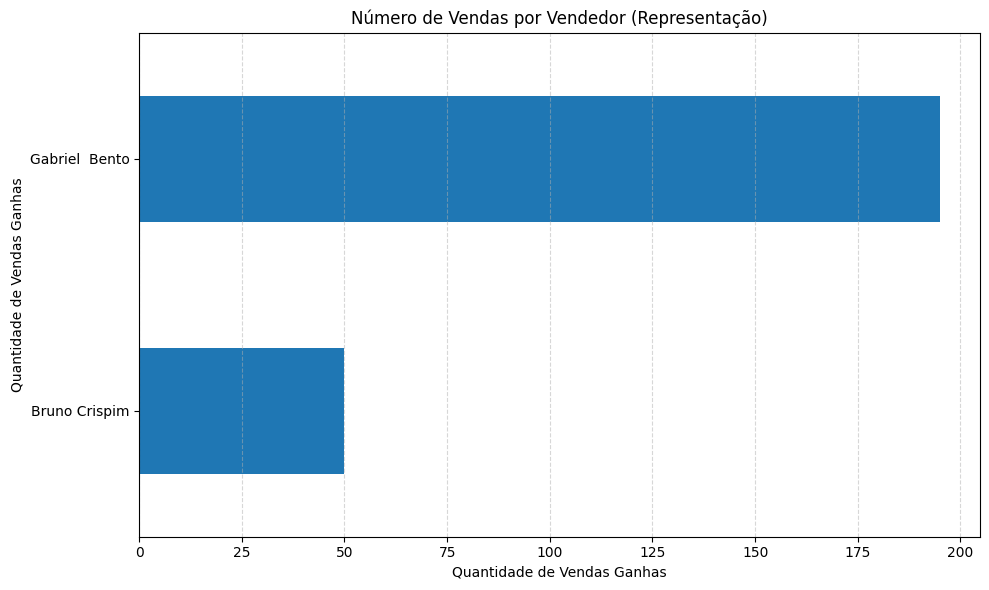

In [91]:
df_rep_ganhas = df_rep[df_rep["deal_stage.name"] == 'Venda Ganha']

vendas_por_vendedor = df_rep_ganhas["user.name"].value_counts().sort_values(ascending=True)


plt.figure(figsize=(10,6))
vendas_por_vendedor.plot(kind="barh")
plt.title('Número de Vendas por Vendedor (Representação)')
plt.xlabel("Quantidade de Vendas Ganhas")
plt.ylabel("Quantidade de Vendas Ganhas")
plt.tight_layout()
plt.grid(axis="x",linestyle = '--', alpha = 0.5)
plt.show()

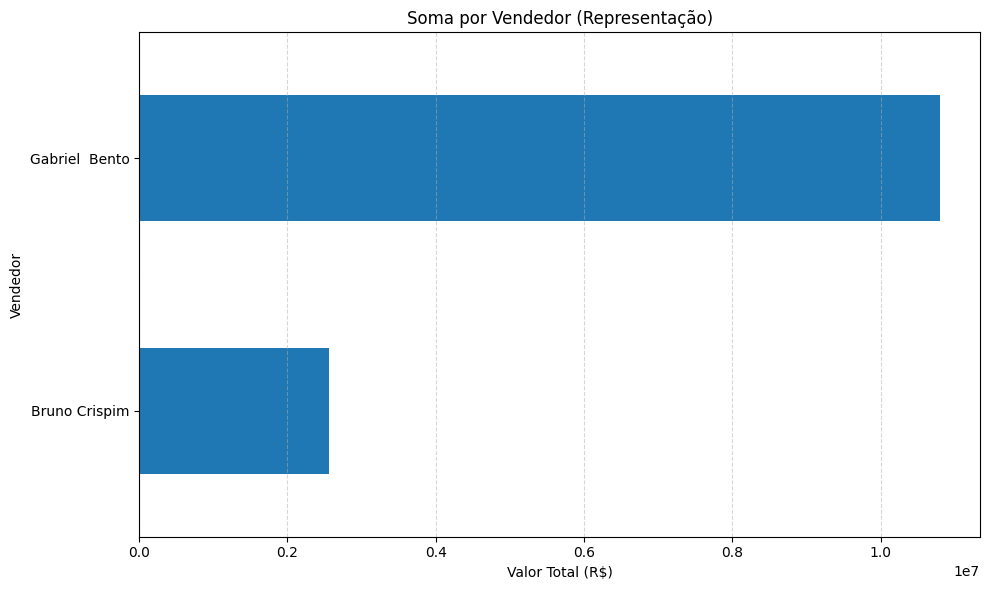

In [92]:
soma_por_vendedor = df_rep_ganhas.groupby('user.name')["amount_total"].sum()


plt.figure(figsize=(10,6))
soma_por_vendedor.plot(kind="barh")
plt.title("Soma por Vendedor (Representação)")
plt.xlabel("Valor Total (R$)")
plt.ylabel("Vendedor")
plt.grid(axis='x', linestyle = '--', alpha = 0.5)
plt.tight_layout()
plt.show()

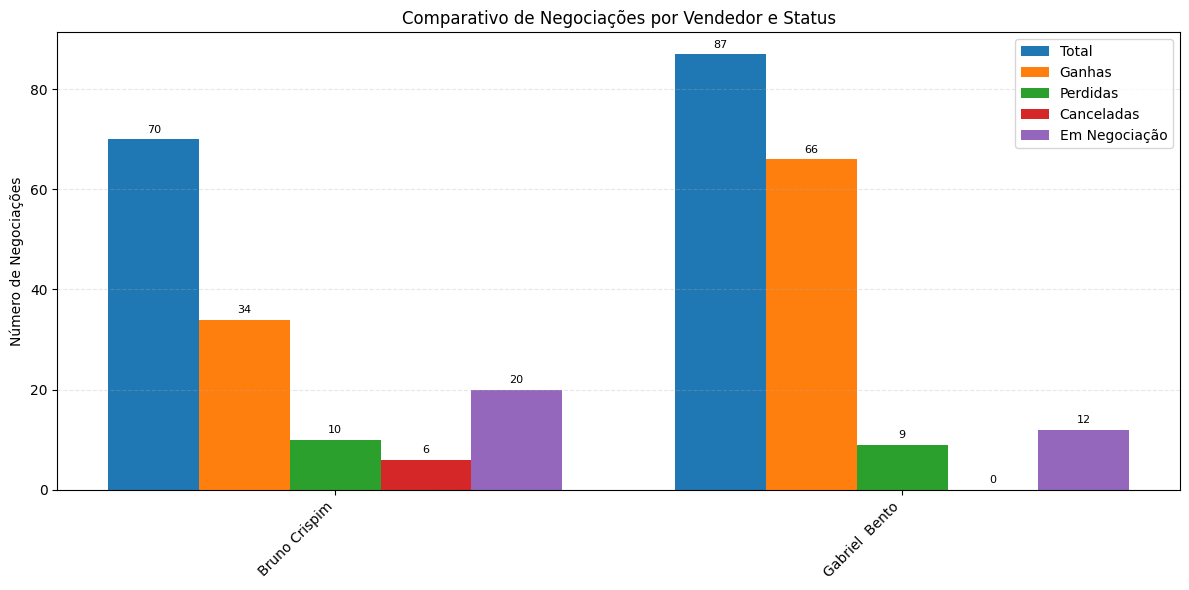

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Supondo df já preparado com counts:
users = counts.index.tolist()
x = np.arange(len(users))
n_barras, total_width = 5, 0.8
bar_width = total_width / n_barras
offsets = np.linspace(-total_width/2 + bar_width/2,total_width/2 - bar_width/2,n_barras)

series = [
    counts["Total"],
    counts["Venda Ganha"],
    counts["Venda Perdida"],
    counts["Venda Cancelada"],
    counts["Negociação"],
]
labels = ["Total", "Ganhas", "Perdidas", "Canceladas", "Em Negociação"]

plt.figure(figsize=(12,6))
bars = []
for off, s, lbl in zip(offsets, series, labels):
    bars.append(plt.bar(x + off, s, bar_width, label=lbl))

plt.xticks(x, users, rotation=45, ha="right")
plt.ylabel("Número de Negociações")
plt.title("Comparativo de Negociações por Vendedor e Status")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)

# anotações
altura_maxima = max(s.max() for s in series)
for bar_container in bars:
    for bar in bar_container:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            h + altura_maxima * 0.01,
            f"{int(h)}",
            ha="center", va="bottom", fontsize=8
        )

plt.tight_layout()
plt.show()

In [94]:
#counts
counts.get("Venda Ganha", pd.Series(0, index=users))

user.name
Bruno Crispim     34
Gabriel  Bento    66
Name: Venda Ganha, dtype: int64

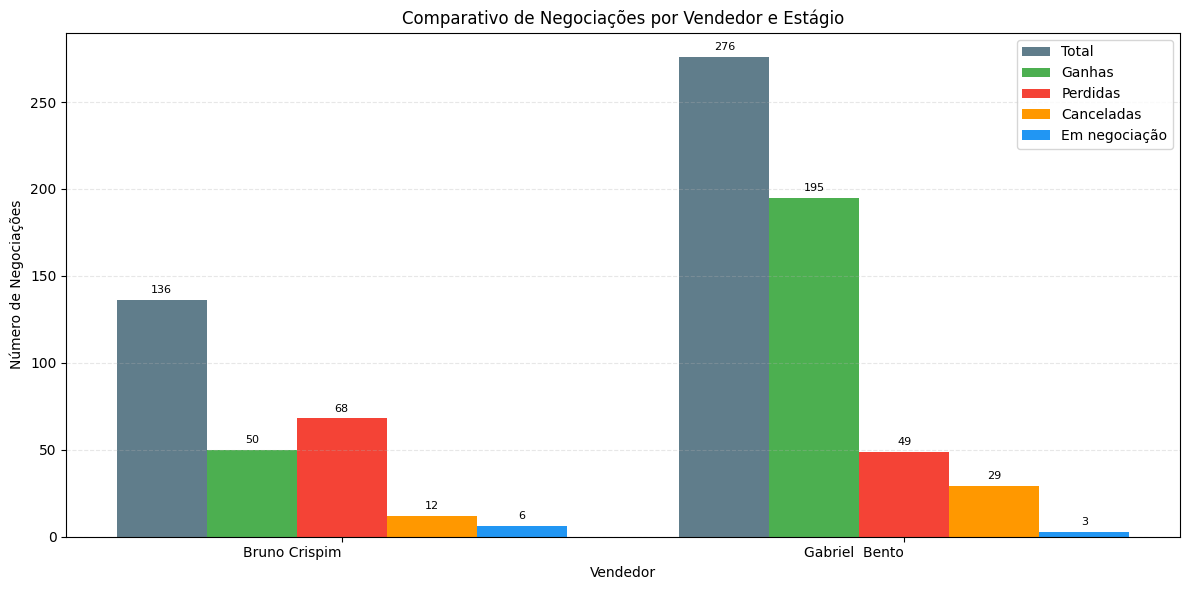

In [95]:
#Definindo os estágios de deal_stage.name que quero pegar
estágios = ["Venda Ganha", "Venda Perdida", "Venda Cancelada", "Negociação"] #lista com os estágios

#Criando DataFrame com os estágios que eu quero
df_rep_graf = df_rep[df_rep["deal_stage.name"].isin(estágios)].copy() #pega as linhas com os estágios de negociação já definidos

#Contando quantas negociações de cada estágio por vendedor
counts = df_rep_graf.groupby(["user.name", "deal_stage.name"]).size().unstack(fill_value=0) #faz a contagem dos estágios por vendedor e preenche os valores nulos por 0

#Adicionando coluna Total somando todos os estágios. 
counts['Total'] = counts.sum(axis=1)  #axis=1 faz a contagem por linha


#Dados para plotar o gráfico
vendedores = counts.index.tolist() #pega o index de counts ou seja o nome dos vendedores e transforma em uma lista python convencional
x = np.arange(len(vendedores)) #Cria um array com o número de vendedores (len(vendedores)) isso vai ser usado para cada vendedor ser posicionado no gráfico
n_barras = 5
total_width = 0.8
bar_width = total_width/n_barras
offsets = np.linspace(-total_width/2 + bar_width/2,total_width/2 - bar_width/2,n_barras)


series = [
    counts["Total"],
    counts.get("Venda Ganha", pd.Series(0, index=vendedores)),
    counts.get("Venda Perdida", pd.Series(0, index=vendedores)),
    counts.get("Venda Cancelada", pd.Series(0, index=vendedores)),
    counts.get("Negociação", pd.Series(0, index=vendedores)),
]

labels = ['Total', 'Ganhas', 'Perdidas', 'Canceladas', "Em negociação"]
colors = ["#607D8B", "#4CAF50", "#F44336", "#FF9800", "#2196F3"]

#Plotando o gráfico
plt.figure(figsize=(12,6))
bars = []

for off, serie, label, color in zip(offsets, series, labels, colors):
    b = plt.bar(x + off, serie, bar_width, label=label, color=color)
    bars.append(b)
    
plt.xticks(x,vendedores, ha='right')
plt.xlabel('Vendedor')
plt.ylabel("Número de Negociações")
plt.title("Comparativo de Negociações por Vendedor e Estágio")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)

#Anotar valores acima de cada barra
altura_maxima = max(s.max() for s in series)
for bar_container in bars:
    for bar in bar_container:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            h + altura_maxima * 0.01,
            f"{int(h)}",
            ha="center", va="bottom", fontsize=8
        )

plt.tight_layout()
plt.show()


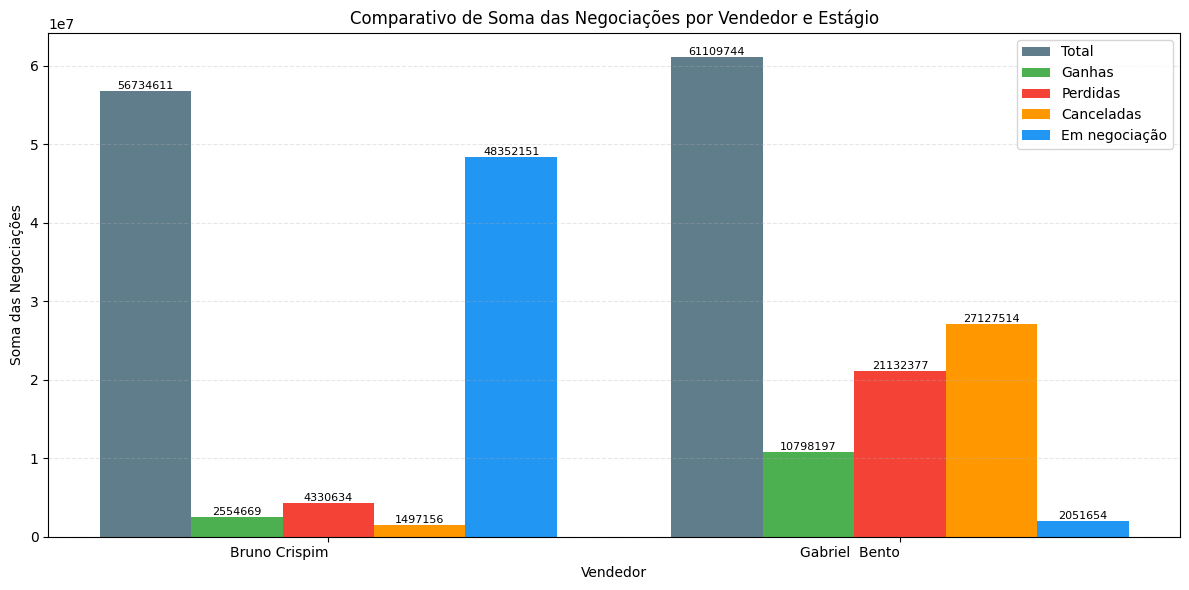

In [96]:
#Definindo os estágios de deal_stage.name que quero pegar
estágios = ["Venda Ganha", "Venda Perdida", "Venda Cancelada", "Negociação"] #lista com os estágios

#Criando DataFrame com os estágios que eu quero
df_rep_graf = df_rep[df_rep["deal_stage.name"].isin(estágios)].copy() #pega as linhas com os estágios de negociação já definidos


#Dados para plotar o gráfico
vendedores = counts.index.tolist() #pega o index de counts ou seja o nome dos vendedores e transforma em uma lista python convencional
x = np.arange(len(vendedores)) #Cria um array com o número de vendedores (len(vendedores)) isso vai ser usado para cada vendedor ser posicionado no gráfico
n_barras = 5
total_width = 0.8
bar_width = total_width/n_barras
offsets = np.linspace(-total_width/2 + bar_width/2,total_width/2 - bar_width/2,n_barras)


#Criando DataFrame com os estágios que eu quero
df_rep_graf = df_rep[df_rep["deal_stage.name"].isin(estágios)].copy() #pega as linhas com os estágios de negociação já definidos
soma = df_rep_graf.groupby(['user.name','deal_stage.name'])["amount_total"].sum().unstack(fill_value=0)

soma['Total'] = soma.sum(axis=1)
soma

series_soma = [
    soma["Total"],
    soma.get("Venda Ganha", pd.Series(0, index=vendedores)),
    soma.get("Venda Perdida", pd.Series(0, index=vendedores)),
    soma.get("Venda Cancelada", pd.Series(0, index=vendedores)),
    soma.get("Negociação", pd.Series(0, index=vendedores)),
]

#Plotando o gráfico
plt.figure(figsize=(12,6))
bars = []

for off, serie, label, color in zip(offsets, series_soma, labels, colors):
    b = plt.bar(x + off, serie, bar_width, label=label, color=color)
    bars.append(b)
    
plt.xticks(x,vendedores, ha='right')
plt.xlabel('Vendedor')
plt.ylabel("Soma das Negociações")
plt.title("Comparativo de Soma das Negociações por Vendedor e Estágio")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)

#Anotar valores acima de cada barra
altura_maxima = max(s.max() for s in series)
for bar_container in bars:
    for bar in bar_container:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            h + altura_maxima * 0.01,
            f"{int(h)}",
            ha="center", va="bottom", fontsize=8
        )

plt.tight_layout()
plt.show()

In [ ]:


caminho = r"C:\\Users\\Orçamento\\OneDrive - GRUPO RETEC\\02. Engenharia\\Dep. Orçamentos\\POWERBI\\AUTOMACAO RD\\data\\negociacoes_rep_2024.xlsx"
df_rep.to_excel(caminho)